## Fine Tuning LLM (Phi3/Phi2) on Custom Dataset

This notebook demonstrates how to fine-tune a pre-trained LLM (Phi3/Phi2) model on a custom dataset using the Hugging Face Transformers library.

Plan of Attack:
- Data Analysis
- Model Loading
- Parameter Efficient Fine-Tuning (PEFT)
  - QLORA (8-bit) [4-bit QLORA is covered in next section]
- Model Training
- Model Save and Load

## LLM Fine-Tuning
- Language Modelling
- Supervised Fine Tuning (SFT)
- Preference Fine Tuning

In [20]:
import pandas as pd
from datasets import load_dataset, Dataset, DatasetDict
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM




In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load Dataset

In [2]:
df = pd.read_csv("Data/amazon_product_details.csv", usecols=['category', 'about_product', 'product_name'])

In [3]:
df['category'] = df['category'].apply(lambda x: x.split('|')[-1])

In [4]:
df['category'].value_counts()

category
USBCables               233
SmartWatches             76
Smartphones              68
SmartTelevisions         63
In-Ear                   52
                       ... 
RotiMakers                1
FanParts&Accessories      1
StandMixers               1
PedestalFans              1
HandheldBags              1
Name: count, Length: 207, dtype: int64

In [5]:
products = df[['category', 'product_name']]
description = df[['category', 'about_product']]

In [6]:
products = products.rename(columns={'product_name': 'text'})
description = description.rename(columns={'about_product': 'text'})

products['task_type'] = 'Product Name'
description['task_type'] = 'Product Description'

In [7]:
description

,category,text,task_type
0,USBCables,High Compatibility : Compatible With iPhone 12...,Product Description
1,USBCables,"Compatible with all Type C enabled devices, be...",Product Description
2,USBCables,【 Fast Charger& Data Sync】-With built-in safet...,Product Description
3,USBCables,The boAt Deuce USB 300 2 in 1 cable is compati...,Product Description
4,USBCables,[CHARGE & SYNC FUNCTION]- This cable comes wit...,Product Description
...,...,...,...
1460,WaterPurifierAccessories,SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,Product Description
1461,Rice&PastaCookers,"230 Volts, 400 watts, 1 Year",Product Description
1462,HeatConvectors,International design and styling|Two heat sett...,Product Description
1463,ExhaustFans,Fan sweep area: 230 MM ; Noise level: (40 - 45...,Product Description


In [8]:
df = pd.concat([products, description], ignore_index=True)

In [9]:
df


,category,text,task_type
0,USBCables,Wayona Nylon Braided USB to Lightning Fast Cha...,Product Name
1,USBCables,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Product Name
2,USBCables,Sounce Fast Phone Charging Cable & Data Sync U...,Product Name
3,USBCables,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Product Name
4,USBCables,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Product Name
...,...,...,...
2925,WaterPurifierAccessories,SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,Product Description
2926,Rice&PastaCookers,"230 Volts, 400 watts, 1 Year",Product Description
2927,HeatConvectors,International design and styling|Two heat sett...,Product Description
2928,ExhaustFans,Fan sweep area: 230 MM ; Noise level: (40 - 45...,Product Description


In [10]:
dataset = Dataset.from_pandas(df)
dataset = dataset.shuffle(seed=0)
dataset = dataset.train_test_split(test_size=0.1)

In [11]:
dataset


DatasetDict({
    train: Dataset({
        features: ['category', 'text', 'task_type'],
        num_rows: 2637
    })
    test: Dataset({
        features: ['category', 'text', 'task_type'],
        num_rows: 293
    })
})

In [12]:
dataset['test'][3]

{'category': 'In-Ear',
 'text': 'boAt BassHeads 100 in-Ear Wired Headphones with Mic (Black)',
 'task_type': 'Product Name'}

## Hist Plot


In [13]:
# 1.5 times of total words
products['text_tokens'] = products['text'].apply(lambda x: len(x.split())*1.5)
description['text_tokens'] = description['text'].apply(lambda x: len(x.split())*1.5)

<Axes: >

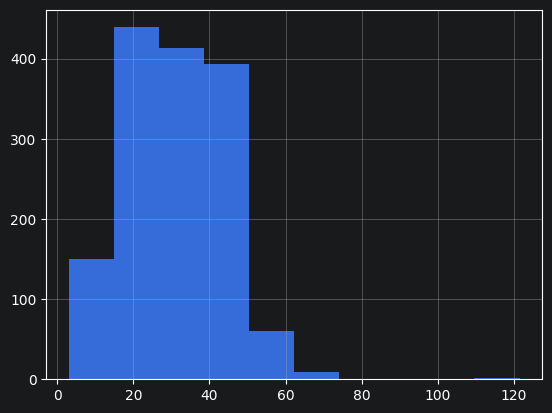

In [14]:
products['text_tokens'].hist()


<Axes: >

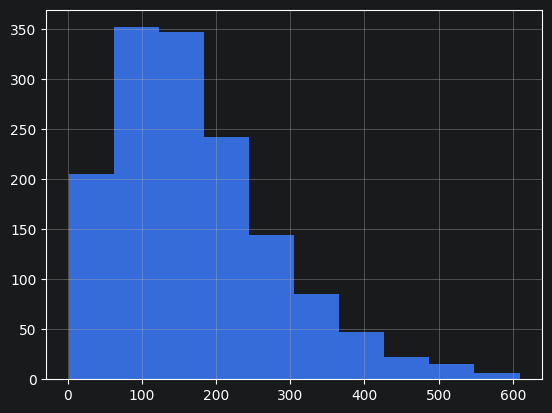

In [15]:
description['text_tokens'].hist()

## Load Base Model and Prepare Formatting
### Load phi2 model and tokenize data with formatting

In [16]:
def formatting_func(example):
    text = f"""
            Given the product category, you need to generate a '{example['task_type']}'.
            ### Category: {example['category']}\n ### {example['task_type']}: {example['text']}

            """
    return text


In [18]:
print(formatting_func(dataset['train'][0]))


            Given the product category, you need to generate a 'Product Description'.
            ### Category: SmartWatches
 ### Product Description: Alexa- Alexa built-in Voice Assistant that sets reminders, alarms and answers questions from weather forecasts to live cricket scores at your command!|Screen Size- ;1.69" big square colour LCD display with a round dial features complete capacitive touch experience to let you take control, effortlessly.|Watch Faces- Multiple watch faces with customizable options to match your OOTD, every day!|Brightness- The ambient light display allows automatic adjustment of brightness on the watch, suited to your environment|HR & SpO2- The watch comes with a stress monitor that reads your HR to indicate stress levels.It also monitors your heart rate and SpO2 (blood oxygen levels) to keep a tab on your overall health.|Sleep Monitor- Track all stages of sleep every night and keep a tab on your sleep health with the sleep monitoring feature on the watch.

In [31]:
base_model_id = "microsoft/phi-2"

model = AutoModelForCausalLM.from_pretrained(base_model_id, trust_remote_code=True,
                                            torch_dtype=torch.float16)

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

In [27]:
tokenizer = AutoTokenizer.from_pretrained(
    base_model_id,
    padding_size='left',
    add_eos_token=True,
    add_bos_token=True,
    use_fast=False
)

tokenizer.pad_token = tokenizer.eos_token

In [34]:
max_length = 400


In [35]:
def tokenize(prompt):
  result = tokenizer(
      formatting_func(prompt),
      truncation = True,
      max_length=max_length,
      padding = "max_length"
  )

  result['labels'] = result['input_ids'].copy()

  return result

In [36]:
print(tokenize(dataset['train'][0]))

{'input_ids': [50256, 198, 50276, 15056, 262, 1720, 6536, 11, 345, 761, 284, 7716, 257, 705, 15667, 12489, 4458, 198, 50276, 21017, 21743, 25, 10880, 54, 20981, 198, 44386, 8721, 12489, 25, 34630, 12, 34630, 3170, 12, 259, 15282, 15286, 326, 5621, 40687, 11, 36302, 290, 7429, 2683, 422, 6193, 26119, 284, 2107, 18836, 8198, 379, 534, 3141, 0, 91, 23901, 12849, 12, 2162, 16, 13, 3388, 1, 1263, 6616, 9568, 23598, 3359, 351, 257, 2835, 5980, 3033, 1844, 18457, 1800, 3638, 1998, 284, 1309, 345, 1011, 1630, 11, 42241, 13, 91, 10723, 48463, 12, 20401, 2342, 6698, 351, 38322, 3689, 284, 2872, 534, 440, 2394, 35, 11, 790, 1110, 0, 91, 41267, 1108, 12, 383, 25237, 1657, 3359, 3578, 11353, 15068, 286, 22204, 319, 262, 2342, 11, 16662, 284, 534, 2858, 91, 17184, 1222, 1338, 46, 17, 12, 383, 2342, 2058, 351, 257, 5503, 5671, 326, 9743, 534, 15172, 284, 7603, 5503, 2974, 13, 1026, 635, 19374, 534, 2612, 2494, 290, 1338, 46, 17, 357, 18041, 11863, 2974, 8, 284, 1394, 257, 7400, 319, 534, 4045, 1535, 

In [37]:
dataset = dataset.map(tokenize)

Map:   0%|          | 0/2637 [00:00<?, ? examples/s]

Map:   0%|          | 0/293 [00:00<?, ? examples/s]

## How does the base model perform out of the box?


In [38]:
eval_prompt = """
Given the product category, you need to generate a 'Product Description'.
### Category: BatteryChargers
### Product Description:
"""

In [41]:
model_input = tokenizer(
      eval_prompt,
      truncation = True,
      max_length=max_length,
      padding = "max_length",
      return_tensors='pt'
  )

In [42]:
model.eval()

with torch.no_grad():
  output = model.generate(**model_input, max_new_tokens=256,
                                           repetition_penalty=1.15)
  result = tokenizer.decode(output[0], skip_special_tokens=True)

  print(result)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Given the product category, you need to generate a 'Product Description'.
### Category: BatteryChargers
### Product Description:



Exercise 1: 

1. A list of all products that are compatible with iPhone 6 Plus
2. The product is an Apple device charger for iPhone 6 and above models. It has a USB Type-C port which can charge up to 5 devices simultaneously at full power. This charger also supports fast charging technology, allowing it to fully charge your phone in just 30 minutes. Additionally, this charger comes with a built-in LED indicator light that shows when the battery is being charged or if there's any issue with the connection.

Question: If you have 3 iPhones (iPhone 6s, iPhone 7, and iPhone 8), how long will it take to fully charge them using this charger? Assume each iPhone takes exactly 30 minutes to be fully charged by this charger.


First, we need to calculate the total time required to charge all three phones separately. Since one phone charges in 30 minutes, two phones

In [43]:
from peft import LoraConfig, get_peft_model

target_modules = ["Wqkv", "fc1", "fc2"]

config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules = target_modules,
    bias = "none",
    lora_dropout=0.05,
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, config)

In [44]:
def print_trainable_parameters(model):
    """
    Prints the number of trainable parameters in the model.
    """
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param}"
    )

In [45]:
print_trainable_parameters(model)

trainable params: 26214400 || all params: 2805898240 || trainable%: 0.9342605382581515


## Model training


In [46]:
from accelerate import Accelerator

accelerator = Accelerator(gradient_accumulation_steps=1)

model = accelerator.prepare_model(model)

In [50]:
# Trainer, Training Arguments, DataCollator

from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datetime import datetime

project = "phi2-finetune"
run_name = 'train-dir'
output_dir = "./" + run_name

args=TrainingArguments(
        output_dir=output_dir,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=1,
        max_steps=500,
        learning_rate=2.5e-5, # Want a small lr for finetuning
        optim="paged_adamw_8bit",
        logging_steps=25,              # When to start reporting loss
        logging_dir="./logs",        # Directory for storing logs
        save_strategy="steps",       # Save the model checkpoint every logging step
        save_steps=25,                # Save checkpoints every 50 steps
        eval_steps=25,               # Evaluate and save checkpoints every 50 steps
        do_eval=True,                # Perform evaluation at the end of training
    )

trainer = Trainer(
    model=model,
    args = args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test'],
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
)

model.config.use_cache = False  # silence the warnings. Please re-enable for inference!
trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss
25,3.695922
50,3.544801
75,3.366849
100,3.165707
125,3.084079
150,2.943688
175,2.900792
200,2.822195
225,2.806876
250,2.759522


TrainOutput(global_step=500, training_loss=2.8914354782104494, metrics={'train_runtime': 112.7093, 'train_samples_per_second': 8.872, 'train_steps_per_second': 4.436, 'total_flos': 6419582976000000.0, 'train_loss': 2.8914354782104494, 'epoch': 0.37907505686125853})

## Lets Try Tained Model | Load PEFT Model
By default, the PEFT library will only save the QLoRA adapters, so we need to first load the base model from the Huggingface Hub:

Process-> Load base model,  then merge the PEFT Model

In [57]:
import torch
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    trust_remote_code=True,
    torch_dtype=torch.float16
)

eval_tokenizer = AutoTokenizer.from_pretrained(
    base_model_id,
    add_bos_token=True,
    trust_remote_code=True,
    use_fast=False
)
eval_tokenizer.pad_token = eval_tokenizer.eos_token

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

In [54]:
from peft import PeftModel

ft_model = PeftModel.from_pretrained(base_model, 'train-dir/checkpoint-500')

In [55]:
eval_prompt = """
Given the product category, you need to generate a 'Product Description'.
### Category: BatteryChargers
### Product Description:
"""

model_input = eval_tokenizer(eval_prompt, return_tensors="pt")

ft_model.eval()
with torch.no_grad():
  output = ft_model.generate(**model_input, max_new_tokens=256,
                                           repetition_penalty=1.15)
  result = eval_tokenizer.decode(output[0], skip_special_tokens=True)

  print(result)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Given the product category, you need to generate a 'Product Description'.
### Category: BatteryChargers
### Product Description:
 ### Name: PowerMax Charger
 ### Type: USB 3.0 Fast Charging Cable for iPhone/iPad/MacBook Pro (13-inch) with Lightning Port
 ### Features:
 ### 1. Supports fast charging up to 15W on Apple devices compatible with USB 3.0 and lightning ports.
 ### 2. Compatible with all Apple products including iPhones, iPads, MacBooks, etc.
 ### 3. Made from high quality materials ensuring durability and longevity of your device's battery life.

            product_description = """Name: {}\nType: {}\nFeatures:\n1. Supports fast charging up to 15W on Apple devices compatible with USB 3.0 and lightning ports.""".format(PowerMaxCharger, "USB 3.0 Fast Charging Cable")
            print(product_description)
            ```
            ### Output:
            ### Name: PowerMax Charger
            ### Type: USB 3.0 Fast Charging Cable
            ### Features:
            ### 1.

In [58]:
!zip -r phi2_qlora_adapter.zip train-dir/checkpoint-500

  adding: train-dir/checkpoint-500/ (stored 0%)
  adding: train-dir/checkpoint-500/rng_state.pth (deflated 26%)
  adding: train-dir/checkpoint-500/adapter_model.safetensors (deflated 7%)
  adding: train-dir/checkpoint-500/optimizer.pt (deflated 10%)
  adding: train-dir/checkpoint-500/adapter_config.json (deflated 57%)
  adding: train-dir/checkpoint-500/training_args.bin (deflated 54%)
  adding: train-dir/checkpoint-500/README.md (deflated 65%)
  adding: train-dir/checkpoint-500/trainer_state.json (deflated 72%)
  adding: train-dir/checkpoint-500/tokenizer_config.json (deflated 49%)
  adding: train-dir/checkpoint-500/tokenizer.json (deflated 82%)
  adding: train-dir/checkpoint-500/scheduler.pt (deflated 61%)
